<a href="https://colab.research.google.com/github/aribarahmanii/Breasttumor/blob/main/dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
from getpass import getpass

os.environ["KAGGLE_API_TOKEN"] = getpass("KGAT_8b7f8270011b57716959ecd71b74d6fd ")

KGAT_8b7f8270011b57716959ecd71b74d6fd ··········


In [2]:
!pip install -q -U kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 3.8 MB/s eta 0:00:00


In [3]:
!kaggle datasets list -s breast-ultrasound

ref                                                              title                                                   size  lastUpdated                 downloadCount  voteCount  usabilityRating  
---------------------------------------------------------------  ------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
aryashah2k/breast-ultrasound-images-dataset                      Breast Ultrasound Images Dataset                   204421470  2021-03-14 04:29:54.023000          73565        503                1  
vuppalaadithyasairam/ultrasound-breast-images-for-breast-cancer  Ultrasound Breast Images for Breast Cancer         591742845  2022-11-03 05:51:50.933000           4848         63             0.75  
orvile/bus-uc-breast-ultrasound                                  BUS_UC - Breast Ultrasound Dataset                 143163924  2025-07-06 00:01:54.773000           1117         36                1  
sabah

In [4]:
!mkdir -p /content/data

!kaggle datasets download \
    -d aryashah2k/breast-ultrasound-images-dataset \
    -p /content/data \
    --unzip

Dataset URL: https://www.kaggle.com/datasets/aryashah2k/breast-ultrasound-images-dataset
License(s): CC0-1.0
100% 195M/195M [00:02<00:00, 102MB/s] 



In [5]:
!find /content/data -maxdepth 2 -type d

/content/data
/content/data/Dataset_BUSI_with_GT
/content/data/Dataset_BUSI_with_GT/normal
/content/data/Dataset_BUSI_with_GT/benign
/content/data/Dataset_BUSI_with_GT/malignant


In [6]:
import os

root = '/content/data/Dataset_BUSI_with_GT'

for cls in ['normal', 'benign', 'malignant']:
    folder = os.path.join(root, cls)

    all_files = os.listdir(folder)

    images = [
        f for f in all_files
        if f.lower().endswith(('.png', '.jpg', '.jpeg'))
        and '_mask' not in f.lower()
    ]

    masks = [
        f for f in all_files
        if '_mask' in f.lower()
    ]

    print(f"{cls:10s} → Images: {len(images):3d} | Masks: {len(masks):3d}")

normal     → Images: 133 | Masks: 133
benign     → Images: 437 | Masks: 454
malignant  → Images: 210 | Masks: 211


File: benign (103).png
Image size: (766, 585)
Image mode: RGB


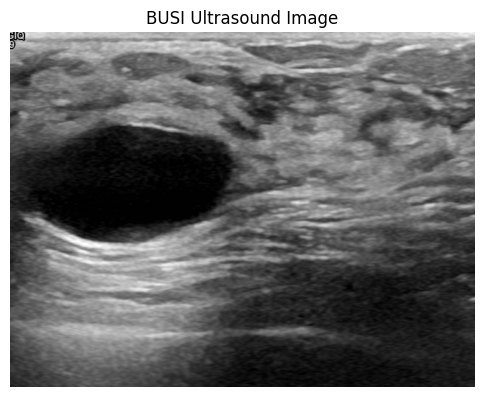

In [7]:
import os
import matplotlib.pyplot as plt
from PIL import Image

folder = os.path.join(root, 'benign')

files = [
    f for f in os.listdir(folder)
    if f.lower().endswith('.png') and '_mask' not in f.lower()
]

image_file = files[0]
image_path = os.path.join(folder, image_file)

image = Image.open(image_path)

print("File:", image_file)
print("Image size:", image.size)
print("Image mode:", image.mode)

plt.figure(figsize=(6, 6))
plt.imshow(image, cmap='gray')
plt.axis('off')
plt.title("BUSI Ultrasound Image")
plt.show()